# 02 — Player seasons

Build the clean, consolidated `player_season` table (2011-12 → 2025-26) from the cached raw responses in `data/raw/`.

## Step 2A — Raw data inventory

`python -m unicorn.download` populates `data/raw/` (703 requests, resumable). Re-running it here costs nothing because every request is already cached. Before any cleaning, check the raw layer is complete and plausible.

In [1]:
import pandas as pd
import numpy as np
from unicorn.download import download_all

log = download_all()   # instant if already downloaded
print(log["status"].str.split(":").str[0].value_counts().to_dict())
log[log["status"].str.startswith("FAILED")]

{'cached': 733}


,endpoint,season,season_type_all_star,measure_type_detailed_defense,per_mode_detailed,rows,status,starter_bench_nullable,distance_range,per_mode_simple,team_id,season_all_time


In [2]:
# Rows per season and endpoint: player counts should be stable (~450-600 regular season)
lds = log[log["endpoint"] == "LeagueDashPlayerStats"]
lds.pivot_table(index="season", columns=["season_type_all_star", "measure_type_detailed_defense"],
                values="rows", aggfunc="first")

season_type_all_star          Playoffs                                  \
measure_type_detailed_defense Advanced Base Defense Misc Scoring Usage   
season                                                                   
2011-12                            204  204     204  204     204   204   
2012-13                            209  209     209  209     209   209   
2013-14                            204  204     204  204     204   204   
2014-15                            208  208     208  208     208   208   
2015-16                            215  215     215  215     215   215   
2016-17                            215  215     215  215     215   215   
2017-18                            210  210     210  210     210   210   
2018-19                            212  212     212  212     212   212   
2019-20                            217  217     217  217     217   217   
2020-21                            239  239     239  239     239   239   
2021-22                            217  217     217  217     217   217   
2022-23                            217  217     217  217     217   217   
2023-24                            214  214     214  214     214   214   
2024-25                            219  219     219  219     219   219   
2025-26                            230  230     230  230     230   230   

season_type_all_star          Regular Season                                  
measure_type_detailed_defense       Advanced Base Defense Misc Scoring Usage  
season                                                                        
2011-12                                  478  478     478  478     478   478  
2012-13                                  469  469     469  469     469   469  
2013-14                                  482  482     482  482     482   482  
2014-15                                  492  492     492  492     492   492  
2015-16                                  476  476     476  476     476   476  
2016-17                                  486  486     486  486     486   486  
2017-18                                  540  540     540  540     540   540  
2018-19                                  530  530     530  530     530   530  
2019-20                                  529  529     529  529     529   529  
2020-21                                  540  540     540  540     540   540  
2021-22                                  605  605     605  605     605   605  
2022-23                                  539  539     539  539     539   539  
2023-24                                  572  572     572  572     572   572  
2024-25                                  569  569     569  569     569   569  
2025-26                                  582  582     582  582     582   582

In [3]:
other = (log[log["endpoint"].isin(["LeagueDashPlayerShotLocations", "LeagueDashPlayerBioStats", "CommonTeamRoster"])]
         .assign(season_type=lambda d: d["season_type_all_star"].fillna("—"))
         .pivot_table(index="season", columns=["endpoint", "season_type"], values="rows", aggfunc="sum"))
other

endpoint    CommonTeamRoster LeagueDashPlayerBioStats  \
season_type                —                        —   
season                                                  
2011-12                  647                      478   
2012-13                  635                      469   
2013-14                  651                      482   
2014-15                  661                      492   
2015-16                  621                      476   
2016-17                  637                      486   
2017-18                  676                      540   
2018-19                  678                      530   
2019-20                  737                      529   
2020-21                  738                      540   
2021-22                  766                      605   
2022-23                  765                      539   
2023-24                  770                      572   
2024-25                  797                      569   
2025-26                  813                      582   

endpoint    LeagueDashPlayerShotLocations                 
season_type                      Playoffs Regular Season  
season                                                    
2011-12                               203            478  
2012-13                               209            469  
2013-14                               204            482  
2014-15                               208            492  
2015-16                               215            476  
2016-17                               215            486  
2017-18                               210            540  
2018-19                               212            530  
2019-20                               215            529  
2020-21                               239            540  
2021-22                               217            605  
2022-23                               217            539  
2023-24                               214            572  
2024-25                               219            569  
2025-26                               230            582

In [4]:
combine = log[log["endpoint"] == "DraftCombineStats"].set_index("season_all_time")["rows"]
print("combine players per draft year:\n", combine.to_string())
print("\nDraftHistory rows:", log.loc[log["endpoint"] == "DraftHistory", "rows"].item())

combine players per draft year:
 season_all_time
2000-01    65
2001-02    78
2002-03    82
2003-04    78
2004-05    81
2005-06    81
2006-07    76
2007-08    77
2008-09    76
2009-10    46
2010-11    52
2011-12    54
2012-13    61
2013-14    63
2014-15    56
2015-16    58
2016-17    56
2017-18    64
2018-19    69
2019-20    77
2020-21    45
2021-22    74
2022-23    83
2023-24    81
2024-25    83
2025-26    79
2026-27    78

DraftHistory rows: 8434


### Roster coverage (listed position, decision D4)

The roster row counts above include the coaches table. What matters is: for each season, what share of player-seasons (and of minutes) get a listed position from that season's rosters?

In [5]:
from nba_api.stats.endpoints import commonteamroster, leaguedashplayerstats
from nba_api.stats.static import teams
from unicorn.download import SEASONS
from unicorn.raw import fetch

def season_rosters(season):
    return pd.concat([fetch(commonteamroster.CommonTeamRoster, team_id=t["id"], season=season)["CommonTeamRoster"]
                      for t in teams.get_teams()], ignore_index=True)

def season_base(season):
    return fetch(leaguedashplayerstats.LeagueDashPlayerStats, season=season, season_type_all_star="Regular Season",
                 measure_type_detailed_defense="Base", per_mode_detailed="Totals")["LeagueDashPlayerStats"]

rows = []
for s in SEASONS:
    ros, base = season_rosters(s), season_base(s)
    has_pos = base["PLAYER_ID"].isin(ros.loc[ros["POSITION"].fillna("") != "", "PLAYER_ID"])
    rows.append({"season": s, "players": len(base), "roster_players": ros["PLAYER_ID"].nunique(),
                 "dup_roster_ids": ros["PLAYER_ID"].duplicated().sum(),
                 "pct_players_with_pos": has_pos.mean(),
                 "pct_minutes_with_pos": base.loc[has_pos, "MIN"].sum() / base["MIN"].sum()})
coverage = pd.DataFrame(rows).set_index("season")
coverage.style.format({"pct_players_with_pos": "{:.1%}", "pct_minutes_with_pos": "{:.1%}"})

,players,roster_players,dup_roster_ids,pct_players_with_pos,pct_minutes_with_pos
season,,,,,
2011-12,478,442,0,92.1%,98.7%
2012-13,469,446,0,93.0%,99.0%
2013-14,482,448,0,90.9%,98.8%
2014-15,492,450,0,90.9%,98.8%
2015-16,476,450,1,93.3%,98.7%
2016-17,486,451,0,91.8%,98.5%
2017-18,540,502,0,91.5%,98.8%
2018-19,530,497,0,91.1%,98.6%
2019-20,529,510,0,94.3%,99.2%


### Step 2A findings

- **All 703 requests are cached with no failures.** The six measure types agree exactly on player counts in every season and season type, so they can be joined one-to-one on `PLAYER_ID`.
- **Regular-season player counts** rise from about 470 (2011-14) to about 570 (2023-26). This reflects two-way contracts (from 2017-18) and larger rosters. **2021-22 has 605** because of COVID health-and-safety replacement signings.
- **Shot locations** occasionally have 1–2 fewer players than Base (2011-12 and 2019-20 playoffs): almost certainly players with zero FGA. We'll left-join and treat missing as 0 attempts.
- **Roster position coverage:** about 91% of player-seasons and about 99% of minutes. The low point is 2021-22 (81.5% of players, 97.5% of minutes), when the COVID call-ups had left rosters by the snapshot date. 2015-16 has one player on two rosters, so deduplicate when joining.
- **Combine:** 45–83 players per draft year. Dips in 2009-10 and 2020-21 (the 2020 combine was virtual).
- **Shortened seasons** to remember for counting stats: 2011-12 (66 games, lockout), 2019-20 (suspension + bubble), 2020-21 (72 games). Rate stats are unaffected; totals and games-played thresholds must be relative to team games.

## Step 2B — Build the clean `player_season` tables

Built by `unicorn.player_season.build_player_seasons()` from the raw cache. Decisions applied:

- **D1** One consolidated row per player-season. Traded players keep `team_count`; `team_abbreviation` = last team.
- **D3** Height and weight as listed that season.
- **D4** Position as listed on that season's roster (`position_listed`). Gaps are filled **only from the player's most recent earlier season** (`position`, with `position_source` showing which). `position_num` maps G=1 … C=5 for the derived-position work (D5).
- **D6** `age` = exact age on **Feb 1** of the season, from roster birth date. Birth date is a fixed fact, so it can come from any season's roster. Fallback: the NBA's integer age (`age_source`).
- **D7** **No rows dropped.** Reliability columns (`min`, `poss`, `fga`, `fta`, `fg3a`) are kept so minutes thresholds can be toggled later.
- **D8** **Playoffs in a separate table** with the same key (stats only, no bio).
- **Draft info from `DraftHistory`** (keyed on player ID), not from bio. The bio endpoint carries wrong records for some players, e.g. Walker Russell Jr. gets his father's 1982 pick. `undrafted` = absent from DraftHistory.
- All percentages are recomputed from makes and attempts, so 0 attempts → NaN. `gs` comes from the "Starters" filter (GP when starting, verified against `PlayerCareerStats`).

In [6]:
from unicorn.player_season import build_player_seasons

ps = build_player_seasons("Regular Season")
po = build_player_seasons("Playoffs")
print("regular season:", ps.shape, "| playoffs:", po.shape)

regular season: (7889, 123) | playoffs: (3230, 107)


### Integrity checks

In [7]:
raw_counts = log[(log["endpoint"] == "LeagueDashPlayerStats") & (log["measure_type_detailed_defense"] == "Base")
                 & log["starter_bench_nullable"].isna()].pivot_table(index="season", columns="season_type_all_star", values="rows")

checks = {
    "unique (player_id, season) — RS": not ps.duplicated(["player_id", "season"]).any(),
    "unique (player_id, season) — PO": not po.duplicated(["player_id", "season"]).any(),
    "RS rows match raw per season": ps.groupby("season").size().equals(raw_counts["Regular Season"].astype(int)),
    "PO rows match raw per season": po.groupby("season").size().equals(raw_counts["Playoffs"].astype(int)),
    "gs <= gp": (ps["gs"] <= ps["gp"]).all(),
    "fgm <= fga, fg3a <= fga": ((ps["fgm"] <= ps["fga"]) & (ps["fg3a"] <= ps["fga"])).all(),
    "drafted no later than the season played": (ps["draft_year"].isna() | (ps["draft_year"] <= ps["season_start"])).all(),
}
pd.Series(checks)

unique (player_id, season) — RS            True
unique (player_id, season) — PO            True
RS rows match raw per season               True
PO rows match raw per season               True
gs <= gp                                   True
fgm <= fga, fg3a <= fga                    True
drafted no later than the season played    True
dtype: bool

In [8]:
# Playoff-only seasons: players signed after the regular season ended
# (e.g. Tracy McGrady → Spurs 2013, Dorell Wright → Heat 2016 after playing in China). Real, not a join error.
po_only = po[~po.set_index(["player_id", "season"]).index.isin(ps.set_index(["player_id", "season"]).index)]
print(len(po_only), "playoff-only player-seasons")
po_only[["player_name", "season", "gp", "min"]]

9 playoff-only player-seasons


,player_name,season,gp,min
214,Tracy McGrady,2012-13,6,31.263333
297,Dwayne Jones,2012-13,2,1.895000
866,Dorell Wright,2015-16,5,18.910000
1017,John Holland,2015-16,1,1.316667
1315,Ty Lawson,2017-18,5,96.300000
1862,Jaylen Adams,2019-20,3,20.733333
2334,Luca Vildoza,2021-22,7,16.936667
2377,Tristan Thompson,2022-23,6,32.341667
2502,DaQuan Jeffries,2022-23,2,4.588333


In [9]:
# Shot zones should account for (nearly) every field-goal attempt. 'corner3' is the sum of
# left + right corner, so zones are: RA + paint + mid + corner3 + atb3 + backcourt.
zone_fga = ps[["ra_fga", "paint_non_ra_fga", "mid_fga", "corner3_fga", "atb3_fga", "backcourt_fga"]].sum(axis=1)
gap = ps["fga"] - zone_fga
print("player-seasons where zones == FGA:", f"{(gap == 0).mean():.1%}")
print("total FGA unaccounted for:", f"{gap.sum() / ps['fga'].sum():.3%}")
gap.describe().round(2)

player-seasons where zones == FGA: 96.0%
total FGA unaccounted for: 0.015%


count    7889.00
mean        0.06
std         0.37
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        10.00
dtype: float64

In [10]:
# Missingness: which columns have gaps, and is it explicable?
na = ps.isna().mean()
na[na > 0].sort_values(ascending=False).to_frame("share_missing").style.format("{:.1%}")

,share_missing
draft_year,22.8%
draft_number,22.8%
draft_round,22.8%
position_listed,8.9%
exp,8.9%
corner3_share,8.1%
fg3_pct,8.1%
ft_pct,4.6%
ast_tov,3.4%
position,3.0%


In [11]:
print(ps["position_source"].value_counts().to_dict())
print(ps["age_source"].value_counts().to_dict())
# The share of *minutes* without any position is what matters for modelling
print("minutes with no position:", f"{ps.loc[ps['position_source'] == 'missing', 'min'].sum() / ps['min'].sum():.2%}")

{'roster': 7189, 'prior_season': 465, 'missing': 235}
{'birth_date': 7708, 'nba_integer': 181}
minutes with no position: 0.24%


### Sanity check: Shai's development

In [12]:
cols = ["season", "team_abbreviation", "age", "height_in", "weight_lb", "position", "gp", "gs", "min",
        "pts_per36", "ast_pct", "usg_pct", "ts_pct", "rim_rate", "fg3a_rate", "pct_uast_fgm"]
ps.loc[ps["player_name"] == "Shai Gilgeous-Alexander", cols].round(3)

,season,team_abbreviation,age,height_in,weight_lb,position,gp,gs,min,pts_per36,ast_pct,usg_pct,ts_pct,rim_rate,fg3a_rate,pct_uast_fgm
3882,2018-19,LAC,20.559,78.0,181.0,G,82,73,2173.907,14.722,0.179,0.182,0.554,0.353,0.194,0.601
4325,2019-20,OKC,21.558,77.0,180.0,G-F,70,70,2428.335,19.732,0.148,0.235,0.568,0.360,0.247,0.709
4804,2020-21,OKC,22.560,78.0,180.0,G-F,35,35,1179.608,25.330,0.311,0.283,0.623,0.395,0.301,0.871
5316,2021-22,OKC,23.559,78.0,180.0,G,56,56,1941.855,25.417,0.293,0.298,0.557,0.299,0.282,0.832
5857,2022-23,OKC,24.559,78.0,195.0,G,68,68,2415.985,31.813,0.249,0.318,0.626,0.361,0.122,0.790
6361,2023-24,OKC,25.558,78.0,195.0,G,75,75,2552.687,31.788,0.287,0.317,0.636,0.303,0.181,0.760
6900,2024-25,OKC,26.560,78.0,195.0,G,76,76,2597.630,34.425,0.299,0.336,0.637,0.255,0.263,0.762
7438,2025-26,OKC,27.559,78.0,195.0,G,68,68,2258.947,33.738,0.332,0.323,0.665,0.276,0.226,0.803


### Save

In [13]:
from unicorn.raw import PROJECT_ROOT

out = PROJECT_ROOT / "data" / "processed"
ps.to_parquet(out / "player_season.parquet", index=False)
po.to_parquet(out / "player_season_playoffs.parquet", index=False)
for f in sorted(out.glob("*.parquet")):
    print(f.name, f"{f.stat().st_size / 1e6:.1f} MB")

player_season.parquet 2.8 MB
player_season_features.parquet 6.1 MB
player_season_playoffs.parquet 1.0 MB
player_season_trajectories.parquet 24.9 MB


### Step 2B findings

- **`player_season`: 7,889 rows × 113 columns; `player_season_playoffs`: 3,230 × 98.** Unique keys, row counts identical to raw for every season.
- **Shot zones reconcile with FGA**: exact for 96% of player-seasons; 0.015% of all attempts unaccounted for (a few unclassified shots).
- **Position**: 7,189 rows from that season's roster, 465 filled from an earlier season, 235 missing (0.24% of minutes).
- **Age**: exact from birth date for 7,708 rows; NBA integer fallback for 181.
- **Data errors found and handled**: bio draft records wrong for some players (fixed by using `DraftHistory`); undrafted players are sometimes coded with blank or 0 picks rather than "Undrafted".
- **9 playoff-only player-seasons** (signed after the regular season). Real; they matter for the later "early playoff experience" analysis.
- **Early signal worth remembering**: Shai's unassisted share of made FGs went 0.60 → 0.71 → 0.87 (2018-19 → 2020-21) *before* his scoring breakout. Self-creation is a strong candidate breakout feature.

## Step 2C — Which columns matter? Redundancy, era drift, and a leakage-safe predictive screen

**Leakage guard.** Choosing features by their correlation with future outcomes *across all seasons* would let 2020-25 results shape the features used to "predict" them. So:

1. **Redundancy** (no outcomes): estimated on 2011-12 → 2016-17 and checked for stability on 2019-20 → 2025-26.
2. **Predictive screen** (uses outcomes): **only the first training window**. Seasons *t* = 2011-12 → 2015-16, outcomes in *t*+1 ≤ 2016-17. So everything learned here was knowable in summer 2017.

Structure is estimated on player-seasons with ≥ 500 minutes; below that, rate stats are mostly noise (Step 1B).

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from unicorn.columns import ROLES, dictionary, features
from unicorn.plotting import apply_style, SURFACE, INK, INK2, BLUE, RED, DIVERGING, FIG_DIR
from unicorn.stats import partial_spearman

apply_style()

ps = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season.parquet")
REL = ps[ps["min"] >= 500]
EARLY, LATE = REL[REL["season_start"] <= 2016], REL[REL["season_start"] >= 2019]
print("reference player-seasons — early:", len(EARLY), "| late:", len(LATE))

reference player-seasons — early: 2083 | late: 2556


### Era drift: why we'll need season-relative features

Minutes-weighted league averages. If a feature's league mean moves a lot, a raw value means different things in 2012 and 2025.

season_start,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fg3a_rate,0.224,0.243,0.260,0.269,0.284,0.317,0.339,0.364,0.388,0.396,0.400,0.390,0.400,0.422,0.416
rim_rate,0.338,0.340,0.337,0.335,0.338,0.334,0.327,0.338,0.333,0.315,0.307,0.315,0.310,0.293,0.301
mid_rate,0.291,0.272,0.255,0.249,0.234,0.209,0.180,0.142,0.123,0.117,0.116,0.107,0.100,0.088,0.090
pace,93.281,93.984,95.835,95.844,97.652,98.025,99.154,101.854,102.042,100.927,99.965,100.887,100.296,100.809,101.496


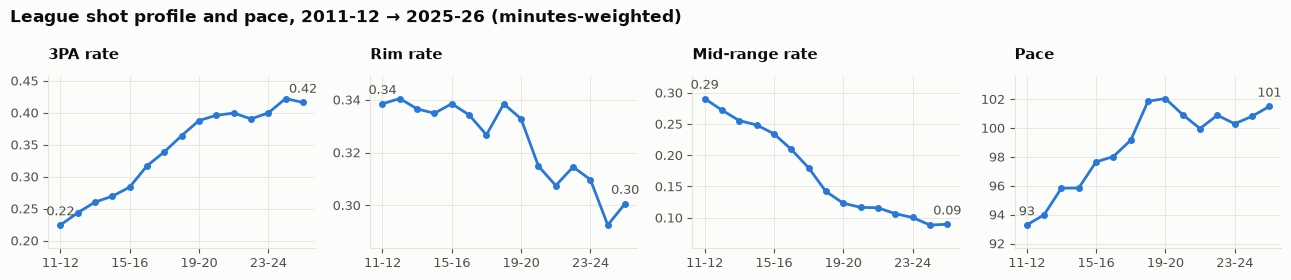

In [15]:
drift_cols = {"fg3a_rate": "3PA rate", "rim_rate": "Rim rate", "mid_rate": "Mid-range rate", "pace": "Pace"}
league = ps.groupby("season_start").apply(lambda g: pd.Series({c: np.average(g[c].dropna(), weights=g.loc[g[c].notna(), "min"])
                                                              for c in drift_cols}), include_groups=False)
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharex=True)
for ax, (c, label) in zip(axes, drift_cols.items()):
    ax.plot(league.index, league[c], color=BLUE, marker="o", markersize=4)
    ax.set_title(label, loc="left", pad=12)
    ax.margins(y=0.18)
    first, last = league[c].iloc[0], league[c].iloc[-1]
    ax.annotate(f"{first:.2f}" if c != "pace" else f"{first:.0f}", (league.index[0], first), xytext=(0, 7), textcoords="offset points", ha="center", color=INK2)
    ax.annotate(f"{last:.2f}" if c != "pace" else f"{last:.0f}", (league.index[-1], last), xytext=(0, 7), textcoords="offset points", ha="center", color=INK2)
    ax.set_xticks([2011, 2015, 2019, 2023], ["11-12", "15-16", "19-20", "23-24"])
fig.suptitle("League shot profile and pace, 2011-12 → 2025-26 (minutes-weighted)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_era_drift.png", dpi=150, bbox_inches="tight")
league.round(3).T

### Redundancy: Spearman correlation among candidate columns

All rate-type columns (kept features + candidate duplicates), clustered so that groups measuring the same thing sit together.

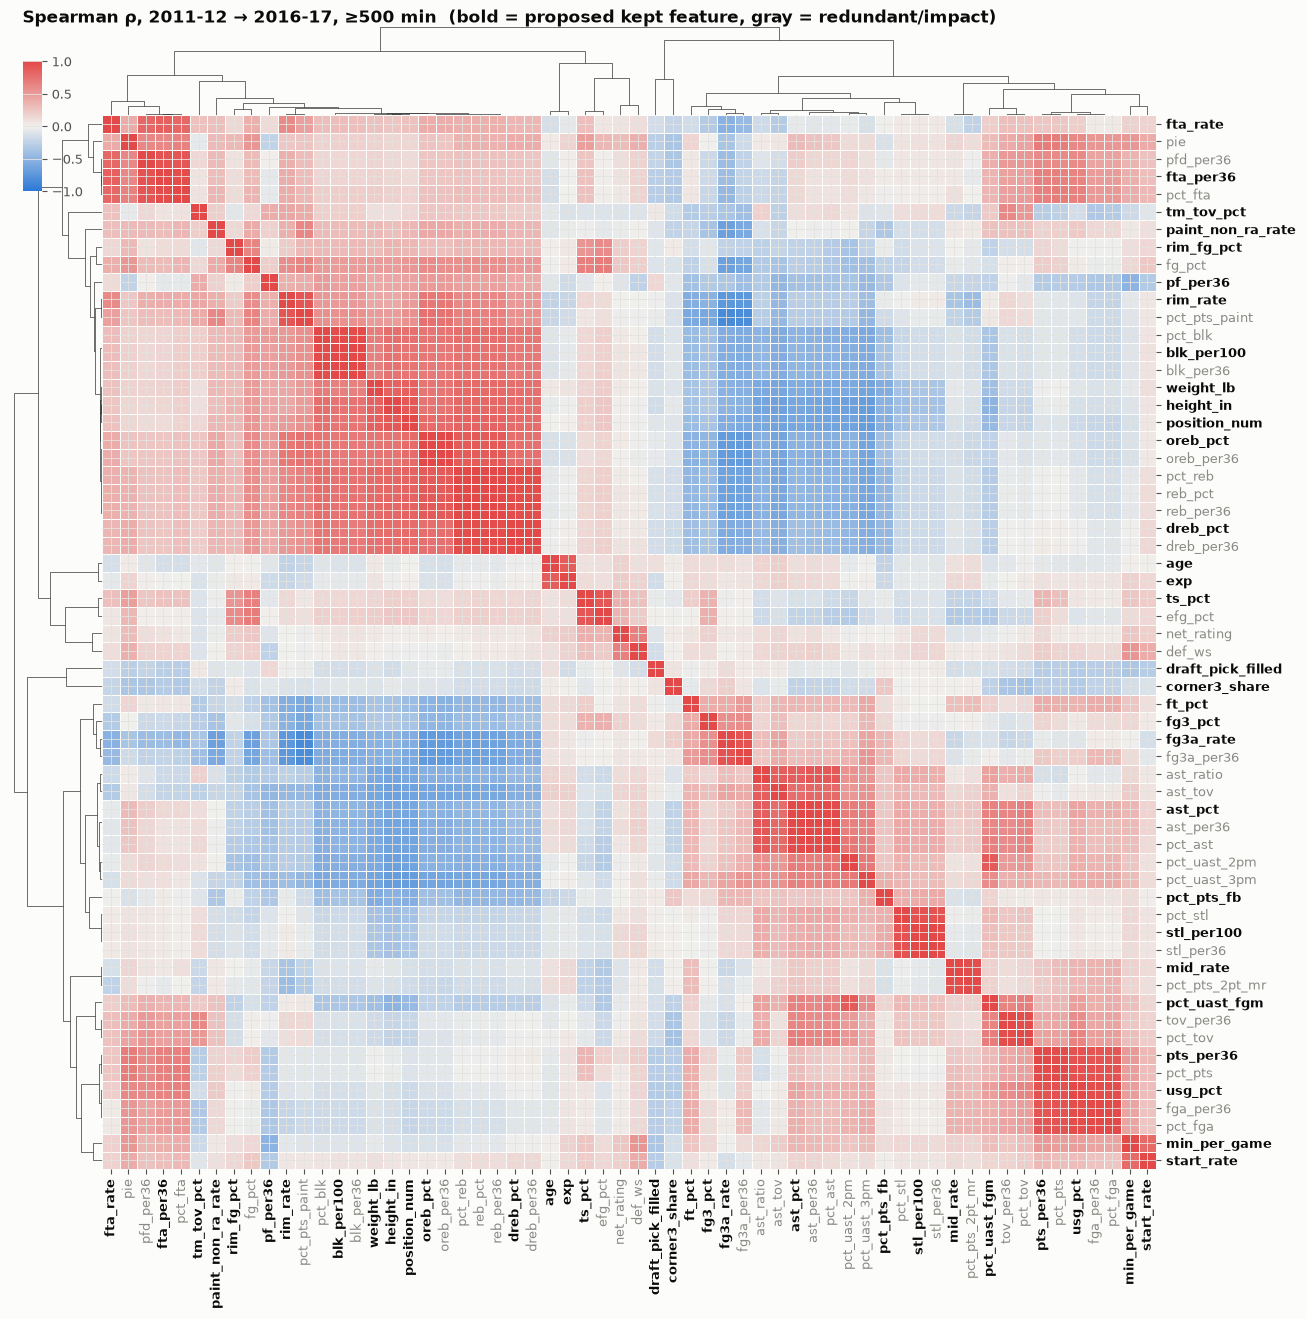

In [16]:
rate_cols = features() + [c for c in ROLES["redundant"] if c in ps.columns] + ["pie", "net_rating", "def_ws"]
corr_early = EARLY[rate_cols].corr(method="spearman")

g = sns.clustermap(corr_early, cmap=DIVERGING, vmin=-1, vmax=1, figsize=(13, 13), method="average",
                   metric="correlation", linewidths=0.4, linecolor=SURFACE, dendrogram_ratio=0.08,
                   cbar_pos=(0.02, 0.86, 0.015, 0.1), xticklabels=True, yticklabels=True)
kept = set(features())
for lab in g.ax_heatmap.get_xticklabels() + g.ax_heatmap.get_yticklabels():
    lab.set_color(INK if lab.get_text() in kept else "#8a8984")
    lab.set_fontweight("bold" if lab.get_text() in kept else "normal")
g.fig.suptitle("Spearman ρ, 2011-12 → 2016-17, ≥500 min  (bold = proposed kept feature, gray = redundant/impact)",
               x=0.02, y=1.0, ha="left", fontsize=12, fontweight="bold")
g.savefig(FIG_DIR / "02_feature_correlation_clustermap.png", dpi=150, bbox_inches="tight")

In [17]:
# Is the redundancy structure stable across eras?
corr_late = LATE[rate_cols].corr(method="spearman")
mask = np.triu(np.ones(corr_early.shape, dtype=bool), k=1)
pairs = pd.DataFrame({"early": corr_early.where(mask).stack(), "late": corr_late.where(mask).stack()}).dropna()
pairs["shift"] = pairs["late"] - pairs["early"]
print(f"pairs: {len(pairs)}   corr(early ρ, late ρ) = {pairs['early'].corr(pairs['late']):.3f}   "
      f"median |shift| = {pairs['shift'].abs().median():.3f}")
print("\nHighly redundant pairs (|ρ_early| ≥ 0.85):")
display(pairs[pairs["early"].abs() >= 0.85].sort_values("early", key=abs, ascending=False).round(2))
print("Largest era shifts:")
pairs.reindex(pairs["shift"].abs().sort_values(ascending=False).index).head(6).round(2)

pairs: 1770   corr(early ρ, late ρ) = 0.954   median |shift| = 0.072

Highly redundant pairs (|ρ_early| ≥ 0.85):


,,early,late,shift
blk_per100,blk_per36,1.00,1.00,0.00
oreb_pct,oreb_per36,1.00,1.00,-0.00
reb_pct,reb_per36,1.00,1.00,-0.00
stl_per100,stl_per36,1.00,1.00,0.00
reb_pct,pct_reb,1.00,1.00,-0.00
dreb_pct,dreb_per36,0.99,0.99,-0.00
reb_per36,pct_reb,0.99,0.99,-0.00
ast_pct,ast_per36,0.99,0.99,-0.00
fga_per36,pct_fga,0.99,0.99,0.00
ast_per36,pct_ast,0.99,0.99,-0.00


Largest era shifts:


early  late  shift
mid_rate          pct_uast_3pm     0.12  0.52   0.40
                  pct_uast_2pm     0.07  0.47   0.39
paint_non_ra_rate ast_per36       -0.03  0.36   0.39
                  ast_pct         -0.00  0.39   0.39
                  pct_ast         -0.02  0.36   0.38
pct_uast_3pm      pct_pts_2pt_mr   0.15  0.51   0.36

### Predictive screen (first training window only)

Provisional outcomes. Real breakout labels come in `05`.

- **Role:** minutes next season (0 if out of the league, so we don't keep only the survivors).
- **Production:** PIE next season (players with ≥ 250 min next season).

Sample: age ≤ 25, ≥ 250 min in season *t*, *t* ∈ 2011-12 … 2015-16.

For each feature we report the **partial Spearman correlation given the player's current level of the outcome and age**: does this stat tell us something about next season that current output doesn't? The 95% CIs come from a cluster bootstrap that resamples whole players.

In [18]:
nxt = (ps[["player_id", "season_start", "min", "pie"]]
       .rename(columns={"min": "min_next", "pie": "pie_next"})
       .assign(season_start=lambda d: d["season_start"] - 1))
screen = (ps[ps["season_start"].between(2011, 2015) & (ps["age"] <= 25) & (ps["min"] >= 250)]
          .merge(nxt, on=["player_id", "season_start"], how="left"))
screen["min_next"] = screen["min_next"].fillna(0)
screen_prod = screen[screen["min_next"] >= 250]
print(f"role sample: {len(screen)} player-seasons, {screen['player_id'].nunique()} players, "
      f"{(screen['min_next'] == 0).mean():.1%} out of league next season | production sample: {len(screen_prod)}")

screen_cols = [c for c in features() if c != "age"] + ["pie", "net_rating", "off_rating", "def_rating", "def_ws"]
results = []
for c in screen_cols:
    role = partial_spearman(screen, c, "min_next", ["min", "age"], n_boot=300)
    prod = partial_spearman(screen_prod, c, "pie_next", ["pie", "age"], n_boot=300) if c != "pie" else {}
    results.append({"feature": c, **{f"role_{k}": v for k, v in role.items()}, **{f"prod_{k}": v for k, v in prod.items()}})
results = pd.DataFrame(results).set_index("feature")
results[["role_estimate", "role_ci_low", "role_ci_high", "prod_estimate", "prod_ci_low", "prod_ci_high"]].round(3)

role sample: 696 player-seasons, 335 players, 7.2% out of league next season | production sample: 595


,role_estimate,role_ci_low,role_ci_high,prod_estimate,prod_ci_low,prod_ci_high
feature,,,,,,
exp,0.085,0.016,0.167,0.137,0.075,0.215
height_in,-0.020,-0.096,0.063,0.082,-0.007,0.172
weight_lb,-0.035,-0.110,0.047,0.042,-0.036,0.129
position_num,-0.005,-0.069,0.065,0.079,0.004,0.161
draft_pick_filled,-0.154,-0.227,-0.075,-0.140,-0.213,-0.061
min_per_game,0.162,0.079,0.251,0.108,0.030,0.182
start_rate,0.048,-0.028,0.130,0.091,0.014,0.171
usg_pct,0.112,0.035,0.195,0.090,0.013,0.168
pts_per36,0.179,0.101,0.253,0.043,-0.032,0.118


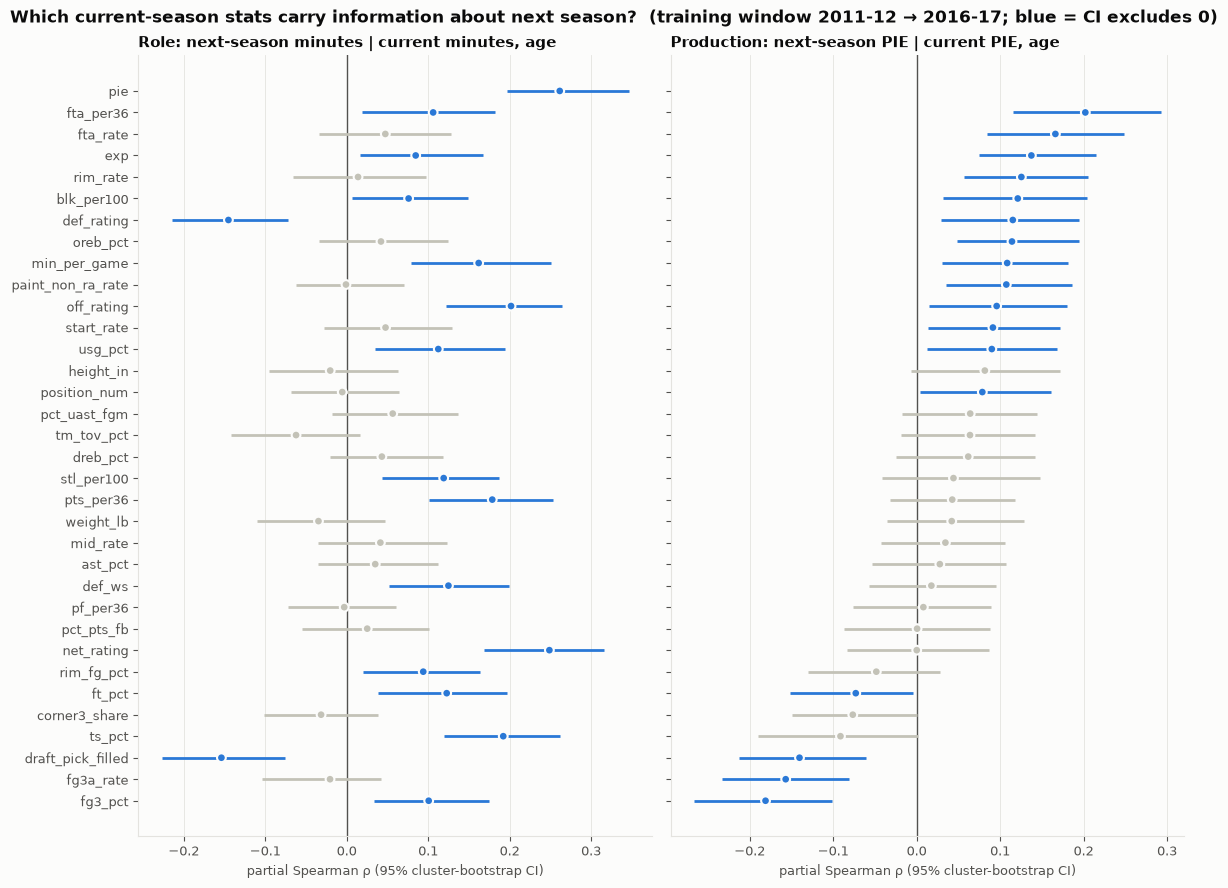

In [19]:
order = results["prod_estimate"].fillna(results["role_estimate"]).sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)
for ax, (key, title) in zip(axes, [("role", "Role: next-season minutes | current minutes, age"),
                                    ("prod", "Production: next-season PIE | current PIE, age")]):
    r = results.loc[order]
    y = np.arange(len(r))
    sig = (r[f"{key}_ci_low"] > 0) | (r[f"{key}_ci_high"] < 0)
    ax.axvline(0, color=INK2, linewidth=1)
    ax.hlines(y, r[f"{key}_ci_low"], r[f"{key}_ci_high"], color=np.where(sig, BLUE, "#c3c2b7"), linewidth=2)
    ax.scatter(r[f"{key}_estimate"], y, s=40, color=np.where(sig, BLUE, "#c3c2b7"), edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_title(title, loc="left"); ax.set_xlabel("partial Spearman ρ (95% cluster-bootstrap CI)")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, order)
fig.suptitle("Which current-season stats carry information about next season?  (training window 2011-12 → 2016-17; blue = CI excludes 0)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_predictive_screen.png", dpi=150, bbox_inches="tight")

### Proposed data dictionary

Every column has exactly one role (`src/unicorn/columns.py`). Roles: identifier · context · reliability · total · **feature** · impact · redundant.

In [20]:
dd = dictionary(ps)
assert dd["in_table"].all() and (dd["role"] != "UNASSIGNED").all(), "dictionary out of sync with table"
print(dd["role"].value_counts().to_dict())
dd[dd["role"].isin(["feature", "redundant"])].sort_values(["role", "column"]).reset_index(drop=True)

{'total': 31, 'feature': 30, 'redundant': 27, 'context': 15, 'reliability': 8, 'identifier': 6, 'impact': 6}


,column,role,duplicates,rho,in_table
0,age,feature,NaN,NaN,True
1,ast_pct,feature,NaN,NaN,True
2,blk_per100,feature,NaN,NaN,True
3,corner3_share,feature,NaN,NaN,True
4,draft_pick_filled,feature,NaN,NaN,True
5,dreb_pct,feature,NaN,NaN,True
6,exp,feature,NaN,NaN,True
7,fg3_pct,feature,NaN,NaN,True
8,fg3a_rate,feature,NaN,NaN,True
9,ft_pct,feature,NaN,NaN,True


### Step 2C findings

**Era drift is large, so season-relative features are needed.** From 2011-12 to 2025-26: 3PA rate 0.22 → 0.42, mid-range rate 0.29 → 0.09, pace 93 → 101. Rim rate fell after 2019-20 (0.33 → 0.30). A raw 3PA rate of 0.35 was high in 2013 and below average in 2024.

**Redundancy is strong and stable across eras** (correlation between the early and late ρ matrices = 0.95). The clusters:
- usage ≈ points/36 ≈ FGA share ≈ points share (ρ 0.93–0.99): keep `usg_pct`. Scoring output ≈ usage × efficiency, so `usg_pct` + `ts_pct` cover `pts_per36`.
- every assist measure (ρ 0.87–0.99): keep `ast_pct`.
- every rebounding measure, which also clusters with height/weight/position: keep `oreb_pct` and `dreb_pct` separately (different skills).
- blocks and steals in their three forms (ρ ≥ 0.94): keep the per-100-possession versions.
- free-throw rate ≈ FTA/36 ≈ fouls drawn (0.81–0.97): keep `fta_rate`.
- rim rate ≈ share of points in the paint (0.92): keep `rim_rate`.

**The biggest era shifts:** mid-range and non-restricted-area paint shooting became tied to self-creation and playmaking (shift ≈ +0.4). Mid-range shots are now taken mainly by on-ball creators.

**Predictive screen (knowable in 2017):**
- **Role** (who gets more minutes) tracks *current* quality: PIE, net/off rating, TS%, draft pick.
- **Production growth** (PIE next | PIE now) tracks different things:
  - **Positive:** free-throw rate, experience-at-age, rim rate, blocks, offensive rebounding, usage.
  - **Negative:** 3P%, 3PA rate, FT%, and a weak negative for TS%.
- **Shooting percentages regress to the mean.** A hot shooting year predicts a decline in production. This is strong support for shrinking percentages toward a prior by attempts.
- **Draft pick matters for both outcomes at equal current output.** It could be a talent signal or team investment (high picks get more opportunity). We can't separate the two yet.
- **Unassisted-FG share is weak here** (CI includes 0). Revisit with real breakout labels.

**Caveats:** two provisional outcomes, about 35 features × 2 tests (expect ~3 nominal false positives), one 5-year window. Treat this as a screen, not a selection procedure. The final feature set will be chosen inside each walk-forward window.

## Step 2D — Reliability shrinkage and season-relative features

Two findings from 2C drive this step:
1. **Shooting percentages regress to the mean**, and the noisiest ones are the most misleading.
2. **The league drifted heavily**, so raw rates aren't comparable across seasons.

**Shrinkage** (`unicorn.features.shrink_percentages`) works as follows:
- For 3P%, FT%, rim FG% and TS%, fit a **beta-binomial prior by maximum likelihood for each season × position group** (guard / forward / big, from *listed* position; season-wide prior if position is unknown).
- Report the posterior mean `(makes + α) / (attempts + α + β)`. The prior is worth `α + β` attempts (`<stat>_prior_n`), so 20 attempts are pulled hard toward the prior and 800 barely move.
- The prior uses only that season's players, which are known at season's end, so there's no leakage.

**Season-relative** (`unicorn.features.season_relative`): for every feature, `<col>_z` and `<col>_pctl` are scaled against that season's rotation players (≥ 500 min). Low-minute players are placed *on* the rotation scale rather than distorting it. Raw columns are kept (D3: height stays as listed; `height_in_z` is an extra view).

In [21]:
from unicorn.features import shrink_percentages, season_relative, SHRINK
from unicorn.columns import relative_columns

feat = shrink_percentages(ps)
priors = (feat.groupby(["season", "prior_group"])[[f"{s}_prior_n" for s in SHRINK]].first()
          .rename(columns=lambda c: c.replace("_prior_n", "")))
print("Prior strength in attempts (α + β), 2018-19 and 2024-25:")
priors.loc[["2018-19", "2024-25"]].round(0)

Prior strength in attempts (α + β), 2018-19 and 2024-25:


fg3_pct  ft_pct  rim_fg_pct  ts_pct
season  prior_group                                     
2018-19 all            349.0    29.0        77.0   137.0
        big             84.0    27.0       144.0   199.0
        forward        328.0    37.0        88.0   156.0
        guard          403.0    34.0       160.0   211.0
2024-25 all            284.0    27.0        81.0   119.0
        big             74.0    18.0        87.0    91.0
        forward        285.0    37.0       107.0   142.0
        guard          351.0    41.0       111.0   161.0

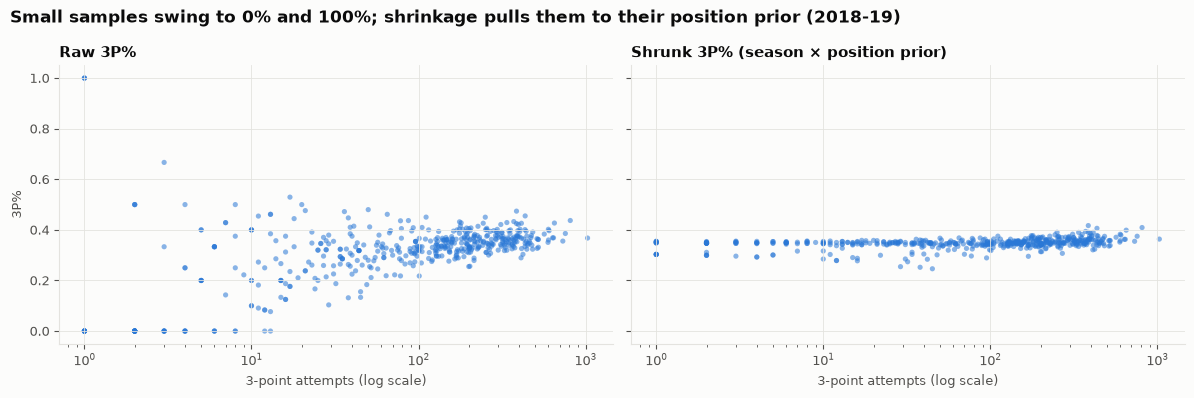

In [22]:
# What shrinkage does: raw vs shrunk 3P% against attempts, one season
s = feat[(feat["season"] == "2018-19") & (feat["fg3a"] > 0) & (feat["prior_group"] != "all")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, title in [(axes[0], "fg3_pct", "Raw 3P%"), (axes[1], "fg3_pct_shr", "Shrunk 3P% (season × position prior)")]:
    ax.scatter(s["fg3a"], s[col], s=14, color=BLUE, alpha=0.55, edgecolor="none")
    ax.set_xscale("log"); ax.set_title(title, loc="left"); ax.set_xlabel("3-point attempts (log scale)")
axes[0].set_ylabel("3P%")
fig.suptitle("Small samples swing to 0% and 100%; shrinkage pulls them to their position prior (2018-19)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_shrinkage_3p.png", dpi=150, bbox_inches="tight")

### Does shrinkage help? Leakage-safe test

Predict next season's *raw* percentage from this season's raw vs shrunk value, on the first training window only (*t* = 2011-12 … 2015-16). Error is weighted by next season's attempts, so noisy next-season values count less.

In [23]:
nxt = feat[["player_id", "season_start", *SHRINK, "fg3a", "fta", "ra_fga", "fga"]].copy()
nxt["tsa"] = nxt["fga"] + 0.44 * nxt["fta"]
nxt["season_start"] -= 1
val = feat[feat["season_start"].between(2011, 2015)].merge(nxt, on=["player_id", "season_start"], suffixes=("", "_next"))

weights = {"fg3_pct": "fg3a_next", "ft_pct": "fta_next", "rim_fg_pct": "ra_fga_next", "ts_pct": "tsa"}
rows = []
for stat, w in weights.items():
    x = val[[stat, f"{stat}_shr", f"{stat}_next", w]].dropna()
    x = x[x[w] > 0]
    wmse = lambda c: np.average((x[c] - x[f"{stat}_next"]) ** 2, weights=x[w])
    rows.append({"stat": stat, "n": len(x), "wMSE_raw": wmse(stat), "wMSE_shrunk": wmse(f"{stat}_shr"),
                 "error_reduction": 1 - wmse(f"{stat}_shr") / wmse(stat)})
pd.DataFrame(rows).set_index("stat").style.format({"wMSE_raw": "{:.5f}", "wMSE_shrunk": "{:.5f}", "error_reduction": "{:.0%}"})

,n,wMSE_raw,wMSE_shrunk,error_reduction
stat,,,,
fg3_pct,1648,0.00448,0.00210,53%
ft_pct,1883,0.00529,0.00374,29%
rim_fg_pct,1894,0.00483,0.00275,43%
ts_pct,1932,0.00204,0.00139,32%


### Season-relative scaling

In [24]:
feat = season_relative(feat, relative_columns())
ref = feat[feat["min"] >= 500]
z_cols = [c for c in feat.columns if c.endswith("_z")]
print(f"{len(z_cols)} z-scored columns; max |reference mean| across seasons = "
      f"{ref.groupby('season')[z_cols].mean().abs().max().max():.1e} (should be ~0)")

# The same raw 3PA rate means different things in different eras
example = (feat[feat["fg3a_rate"].between(0.345, 0.355) & (feat["min"] >= 500)]
           .groupby("season_start")[["fg3a_rate", "fg3a_rate_z", "fg3a_rate_pctl"]].mean())
example.round(2).T

34 z-scored columns; max |reference mean| across seasons = 6.2e-15 (should be ~0)


season_start,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fg3a_rate,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35,0.35
fg3a_rate_z,0.56,0.45,0.45,0.35,0.36,0.18,0.06,-0.07,-0.21,-0.25,-0.24,-0.23,-0.25,-0.34,-0.35
fg3a_rate_pctl,0.69,0.65,0.62,0.61,0.61,0.54,0.48,0.46,0.37,0.37,0.37,0.38,0.36,0.34,0.31


In [25]:
dd = dictionary(feat)
assert dd["in_table"].all() and (dd["role"] != "UNASSIGNED").all()
print(feat.shape, dd["role"].value_counts().to_dict())

feat.to_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_features.parquet", index=False)
print("saved player_season_features.parquet")

(7889, 200) {'season_relative': 68, 'total': 31, 'feature': 30, 'redundant': 27, 'context': 16, 'reliability': 12, 'identifier': 6, 'impact': 6, 'shrunk': 4}
saved player_season_features.parquet


### Step 2D findings

- **Shrinkage works.** On the 2011-12 → 2015-16 training window it cuts next-season prediction error by **53% (3P%), 43% (rim FG%), 32% (TS%), 29% (FT%)**. The shrunk 3P% leaders in 2018-19 are Joe Harris, Curry, Danny Green, Hield; the raw leaders were 1-for-1 garbage-time shooters.
- **The priors are strong for 3P%** (about 300–400 attempts for guards and forwards, so even a 400-attempt season is pulled roughly halfway). That is consistent with how slowly 3P% stabilizes. Bigs get a much weaker prior (about 75–85 attempts) because stretch bigs and non-shooters differ a lot. FT% has a weak prior (about 20–40 attempts) because players differ a lot in true FT skill.
- **Season-relative scaling removes era drift.** A 3PA rate of 0.35 drops from the 69th percentile (2011-12) to the 31st (2025-26).
- **Output:** `player_season_features.parquet`, 7,889 × 200 (raw + 4 shrunk + 34 z-scored + 34 percentile columns). Every column has a role.

**Natural next improvement (Step 3):** the prior here is the *league* (season × position). Once we have trajectories, a player's own **previous seasons** become a better prior. That is the time-respecting way to estimate true talent.